# Constraint Plotting: Manual Parameter Exploration

This notebook shows how to generate constraint plots by **manually defining source parameters**, without running waveform propagation.

## Use Cases:
- Theoretical parameter space exploration
- Quick constraint plot generation
- Testing different source configurations

## What you'll get:
- Constraint plot in parameter space

## What you won't get:
- Spectrogram (requires propagation - see `examples_complete_workflow.ipynb`)

In [19]:
import numpy as np
from inputs.source import Source
from inputs.spectrum import SignalModel
from inputs.experiment import Experiment
from utils.constants import YEAR_TO_SEC, DAY_TO_SEC
from utils.expt_params import DM_SENSITIVITIES, ENERGY_DENSITY_FRACTIONS
from plotting.output_handler import OutputHandler
from plotting.plots import Plot

## Approach 1: Manually Define Source Parameters

Define your source parameters directly without any propagation.

### Example 1: Single Source (1x1 Plot)

In [20]:
# --- Example 1 Parameters ---

# Source
Etot = 0.01                  # Total energy [solar masses]
mass = 1e-21                 # Scalar field mass [eV]
tstar = 1                    # Burst duration [seconds]
R = 10000.0                  # Distance [parsecs]
ULB_type = 'scalar'             # Type: 'scalar' or 'ALP'
coupling_type = 'electron'   # Coupling: 'photon', 'electron', 'gluon'
coupling_order = 'linear'      # Order: 'linear' or 'quad'

In [21]:
# Define source parameters
source = Source(
    Etot=Etot,
    mass=mass,
    tstar=tstar,
    R=R,
    ULB_type=ULB_type,
    coupling_type=coupling_type,
    coupling_order=coupling_order
)

print(f'Source configuration:')
print(f'  mass = {source.mass} eV')
print(f'  R = {source.R} pc')
print(f'  tstar = {source.tstar} s')
print(f'  Etot = {source.Etot / 1.989e66:.4f} solar masses')
print(f'  coupling_type = {source.coupling_type}')
print(f'  coupling_order = {source.coupling_order}')

Source configuration:
  mass = 1e-21 eV
  R = 10000.0 pc
  tstar = 1.0 s
  Etot = 0.0056 solar masses
  coupling_type = electron
  coupling_order = linear


#### Configure Experiment and Generate Constraint Plot

In [22]:
# Experiment
integration_time = YEAR_TO_SEC      # Integration time for transient search [s]
integration_time_DM = 1e6           # Integration time for DM search [s]
sensitivity = DM_SENSITIVITIES[coupling_type]

# Define experiment parameters
experiment = Experiment(
    integration_time=integration_time,
    integration_time_DM=integration_time_DM,
    sensitivity=sensitivity,
    time_delays={'day': DAY_TO_SEC, 'year': YEAR_TO_SEC}
)

# Create signal model
signal_model = SignalModel(source=source, experiment=experiment)

print('Signal model created successfully')

Signal model created successfully


Constraint plot saved to plots/constraints_manual.png


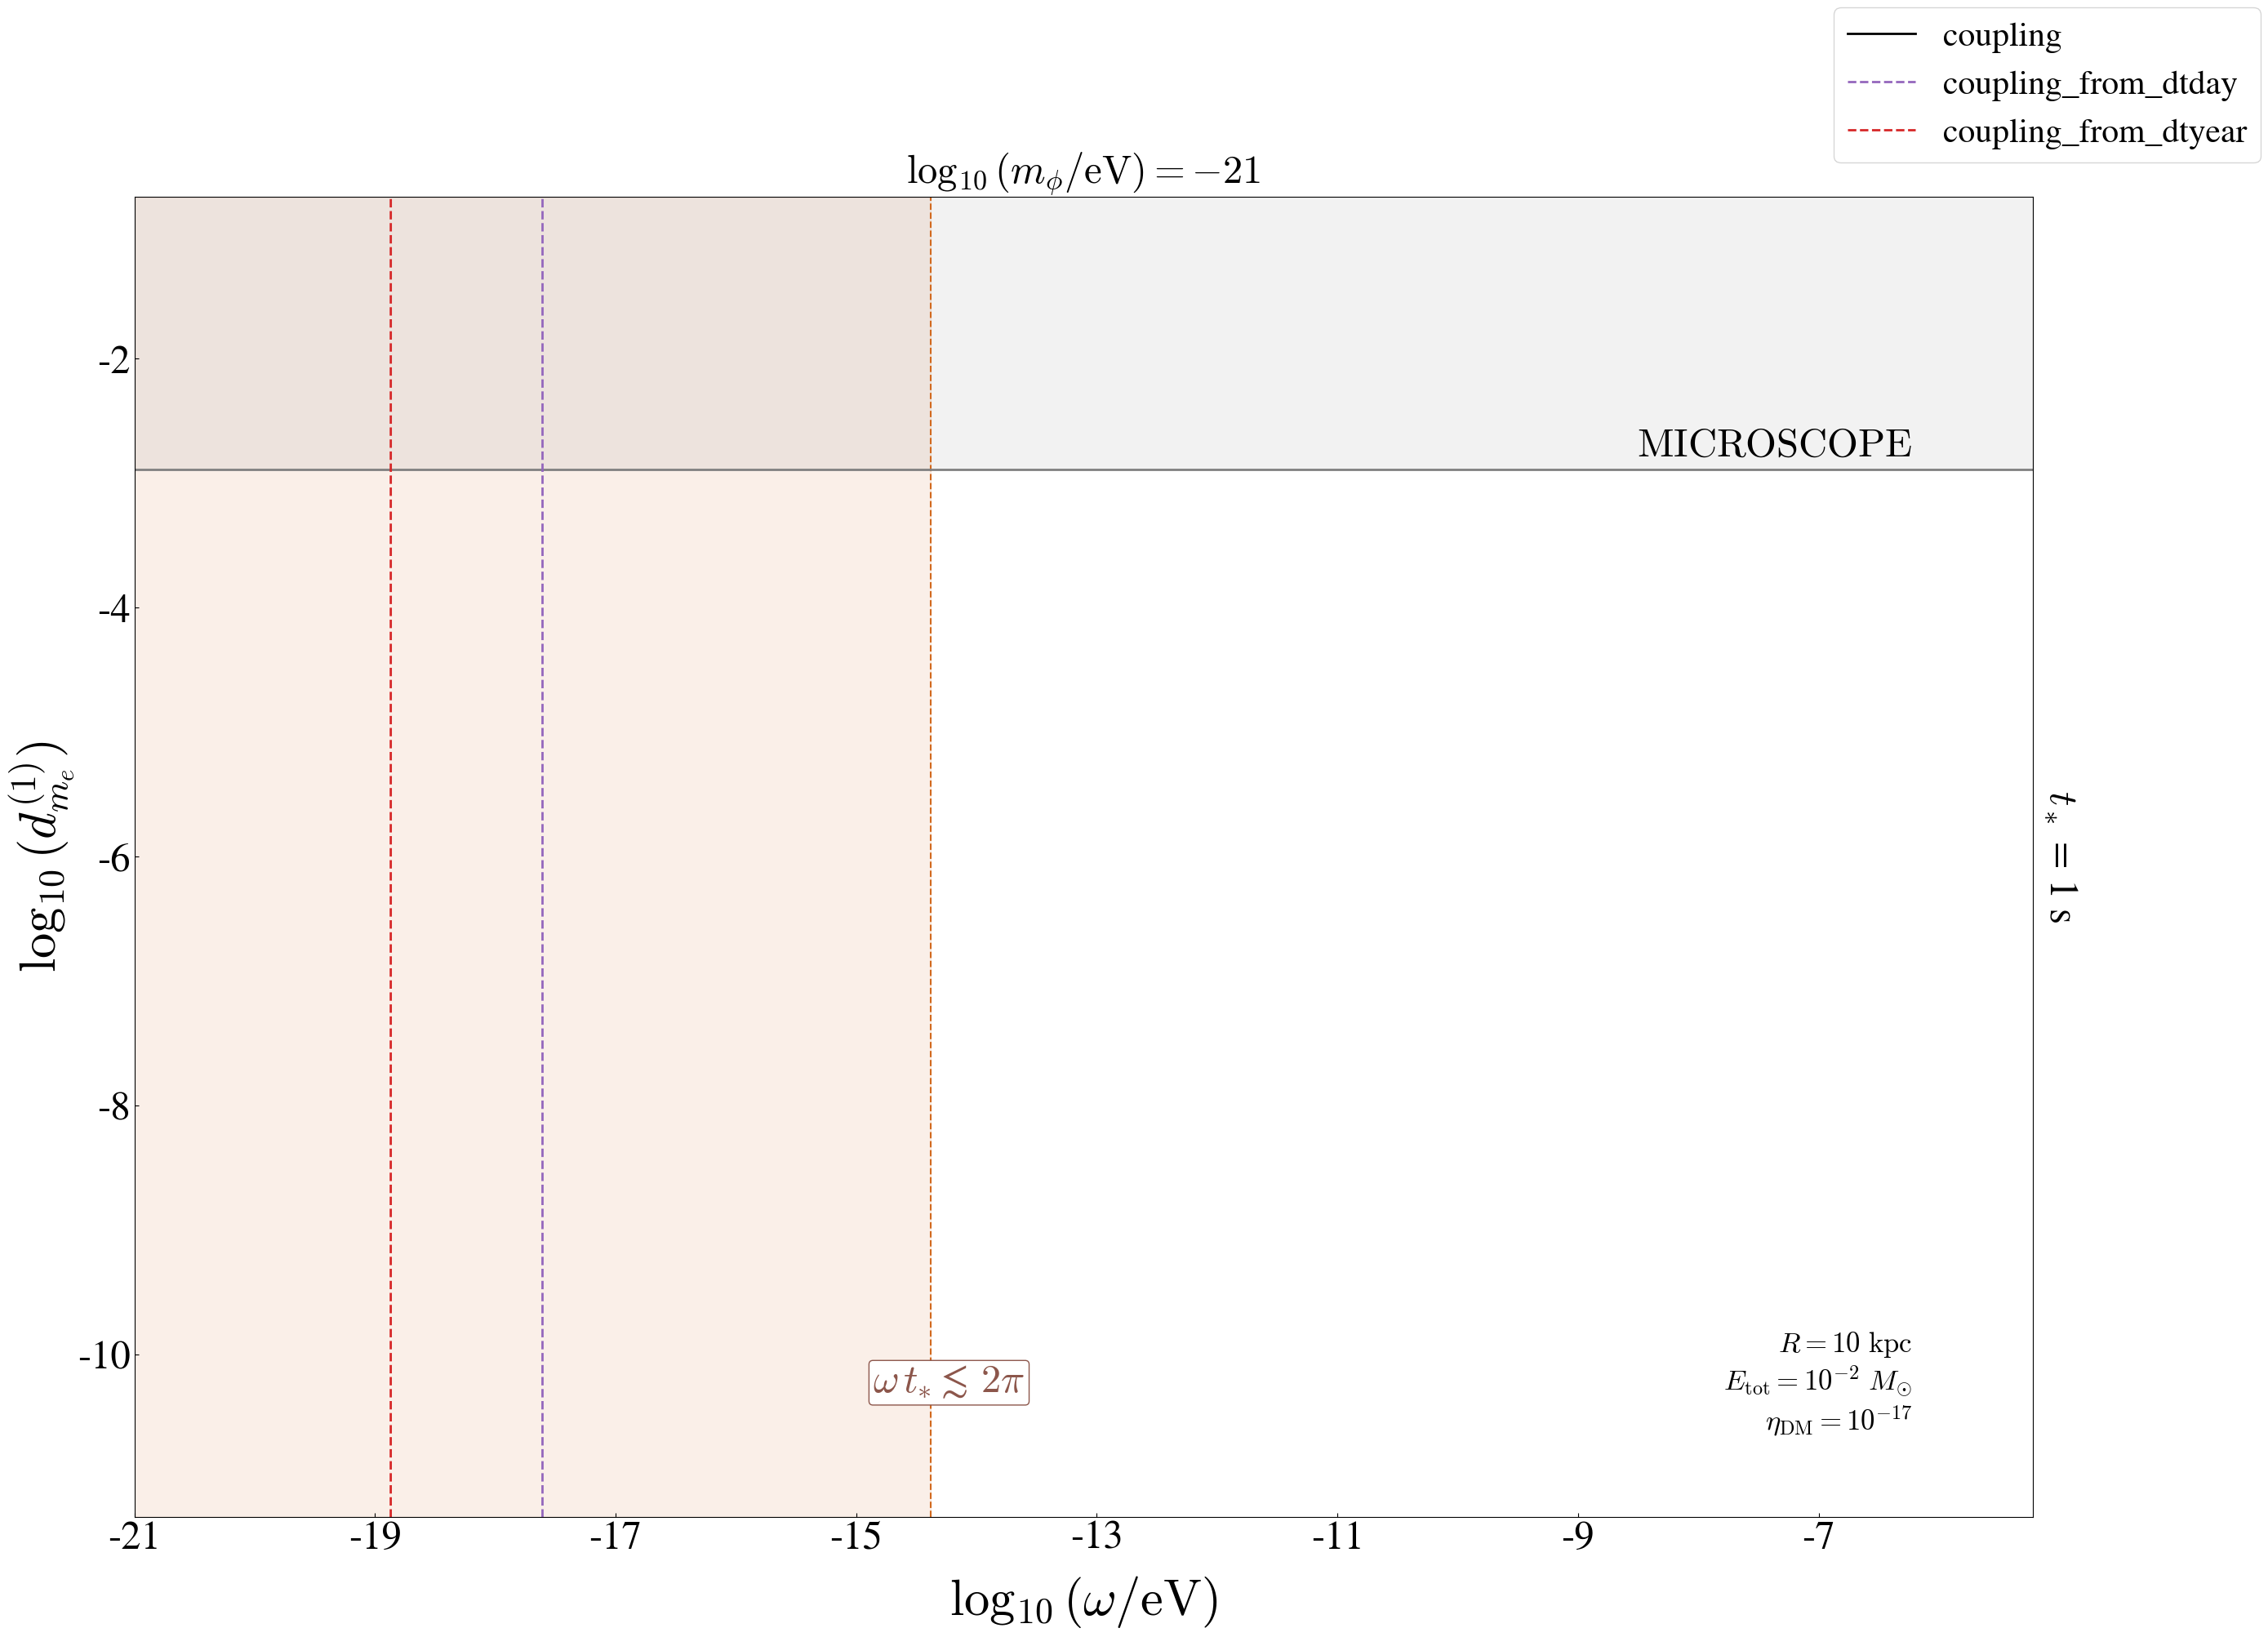

In [23]:
# Constraint plot
xlims = (1e-21, 6e-6)        # Mass axis range [eV]
ylims = (5e-12, 2e-1)        # Coupling axis range

# Generate constraint plot
plot = Plot(
    xlims=xlims,
    ylims=ylims,
    exclude_mass=False,
    include_legend=True
)

output = OutputHandler(plot)
output.plot_parameter_space(
    source, 
    signal_model, 
    plot, 
    save_path='plots/constraints_manual.png',
)

print('Constraint plot saved to plots/constraints_manual.png')

## Example 2: 2x2 Parameter Grid

Create a grid of constraint plots varying mass and burst duration:

In [24]:
# --- Example 2 Parameters ---
masses = [1e-21, 1e-18]      # Two different masses [eV]
times = [1, 100]             # Two different burst durations [seconds]
Etot = 0.01                  # Total energy [solar masses]
R_grid = 1e4                 # Distance [parsecs]
ULB_type_grid = 'scalar'     # Type: 'scalar' or 'ALP'
coupling_type = 'electron'     # Coupling type
coupling_order = 'linear'

# Create 2x2 grid of sources
sources_grid = [
    [Source(
        Etot=Etot, 
        mass=m, 
        tstar=t, 
        R=R_grid, 
        ULB_type=ULB_type_grid, 
        coupling_type=coupling_type,
        coupling_order=coupling_order
    ) for m in masses] 
    for t in times
]

In [25]:
# Define experiment parameters
integration_time = YEAR_TO_SEC      # Integration time for transient search [s]
integration_time_DM = 1e6           # Integration time for DM search [s]
sensitivity = DM_SENSITIVITIES[coupling_type]
K = ENERGY_DENSITY_FRACTIONS['space'][coupling_type]  # Energy density fraction
Dg = 30e3                           # Distance per galaxy for IGM screening [pc]
Dg_secondary = 1e3

experiment = Experiment(
    integration_time=integration_time,
    integration_time_DM=integration_time_DM,
    sensitivity=sensitivity,
    time_delays={'day': DAY_TO_SEC, 'year': YEAR_TO_SEC},
    K=K,
    Dg=Dg,
    Dg_secondary=Dg_secondary
)

In [26]:
# Create signal models
signal_models_grid = [
    [SignalModel(source=s, experiment=experiment) for s in row] 
    for row in sources_grid
]
print('Signal model created successfully')


print(f'Created 2x2 grid with:')
print(f'  Masses: {masses} eV')
print(f'  Burst durations: {times} s')

Signal model created successfully
Created 2x2 grid with:
  Masses: [1e-21, 1e-18] eV
  Burst durations: [1, 100] s


2x2 constraint plot saved to plots/constraints_2x2.png


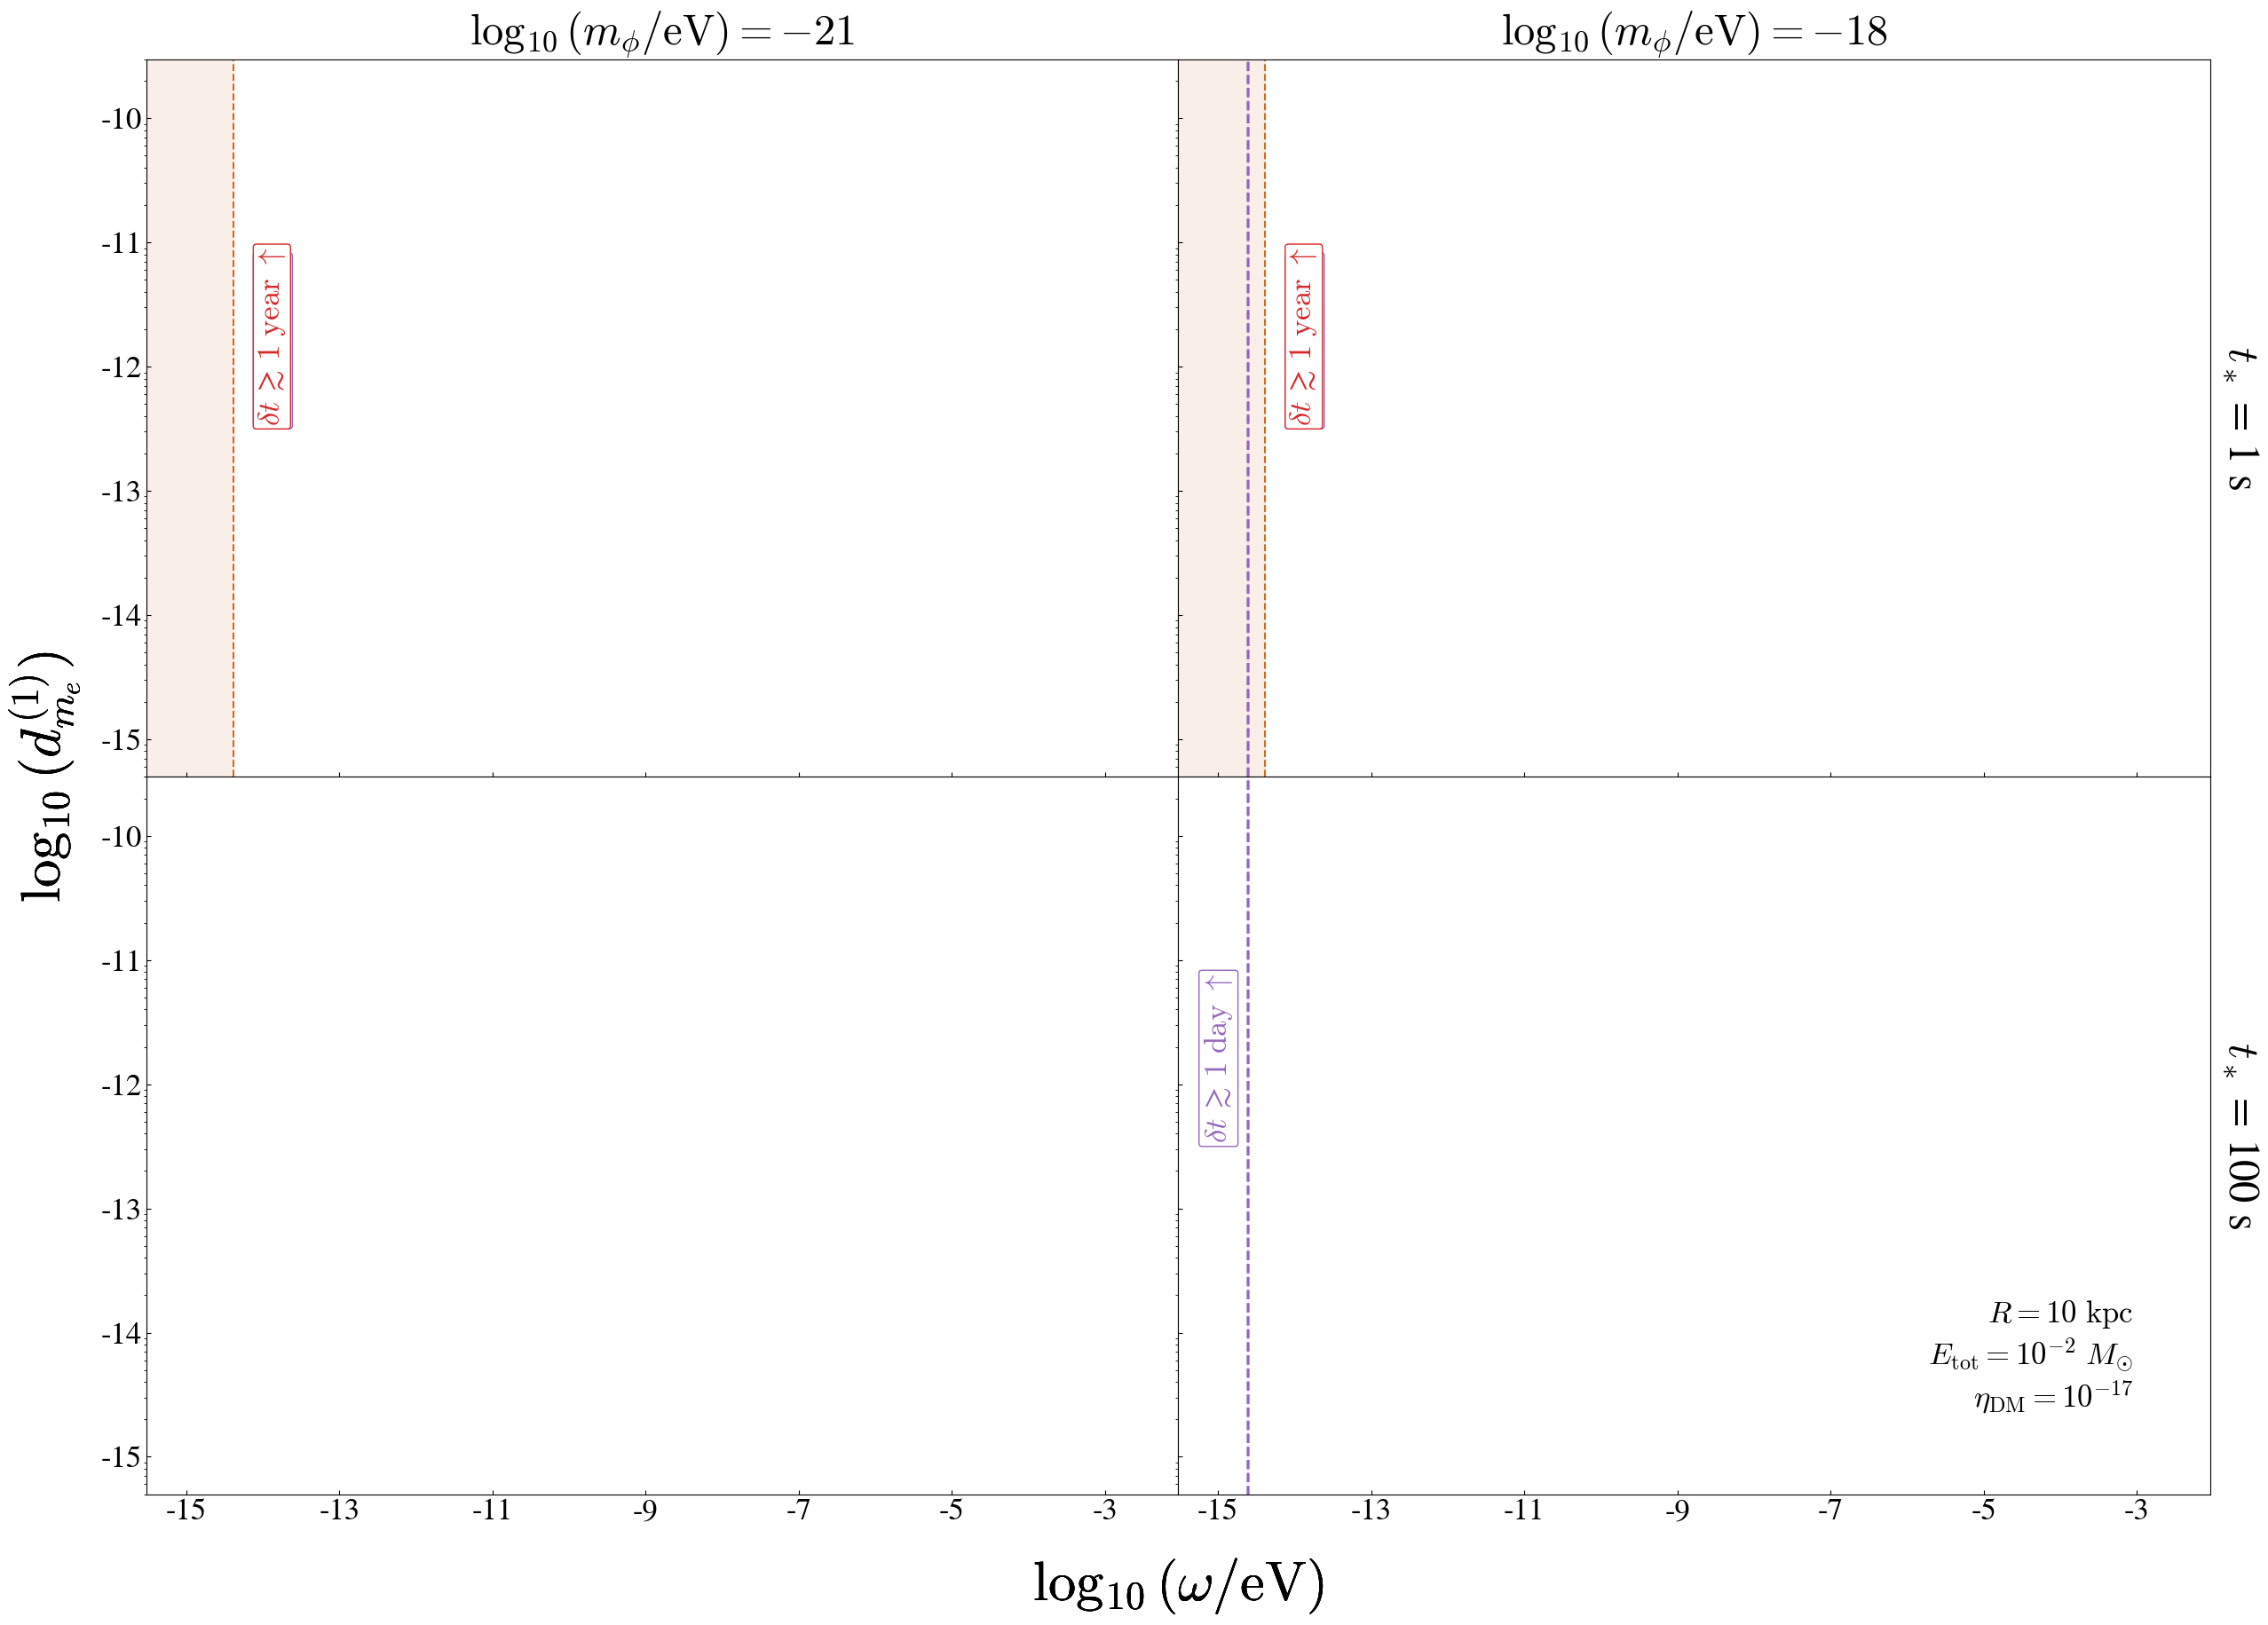

In [ ]:
# Constraint plot
xlims = (.3e-20, 0.9e-6)     # Mass axis range [eV]
ylims = (.5e-19, 3e-1)         # Coupling axis range (photon quad)
legend_bbox = (0.88, 0.88)   # Legend anchor position

# Configure plot with custom legend position
legend_config = {
    'frameon': False,
    'bbox_to_anchor': legend_bbox
}

plot_2x2 = Plot(
    xlims=xlims, 
    ylims=ylims, 
    exclude_mass=False, 
    include_legend=False, 
    legend_config=legend_config,
    label_positions={
        'E_unc': (1e-18, 2e8),
        'mass_exclusion':  (1e-20, 1e15), 
        'crit_screening': {'exp': (5e-13, 2e25),
                           'atm': (4e-11, 5e20),
                           'eth': (1e-13, 8e10)}
    }
)

output_2x2 = OutputHandler(plot_2x2)
output_2x2.plot_parameter_space(
    sources_grid, 
    signal_models_grid, 
    plot_2x2, 
    save_path='plots/constraints_2x2.png'
)

print('2x2 constraint plot saved to plots/constraints_2x2.png')

---

## Summary

This notebook demonstrated manual parameter exploration with:
1. **Example 1: Single source (1x1 plot)** - Basic constraint plot generation
2. **Example 2: Parameter grid (2x2 plot)** - Varying mass and burst duration

For the **complete workflow** including spectrogram generation, see `examples_complete_workflow.ipynb`.